Install and testing

In [ ]:
!pip install -q transformers torch matplotlib Pillow

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import os
from PIL import Image
import matplotlib.pyplot as plt
from transformers import SegformerImageProcessor, AutoModelForSemanticSegmentation
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
image_dir = "/content/drive/MyDrive/DiffVax_Data/train/images/"
image_name = "image_0.png"
image_path = os.path.join(image_dir, image_name)
image = Image.open(image_path).convert("RGB")

In [ ]:
model_id = "mattmdjaga/segformer_b2_clothes"
processor = SegformerImageProcessor.from_pretrained(model_id)
model = AutoModelForSemanticSegmentation.from_pretrained(model_id)

Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

inputs = processor(images=image, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model(**inputs)

logits = outputs.logits.cpu()
upsampled_logits = nn.functional.interpolate(
    logits,
    size=image.size[::-1],
    mode="bilinear",
    align_corners=False,
)

pred_seg = upsampled_logits.argmax(dim=1)[0].numpy()

/tmp/ipykernel_1484/479719656.py:16: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask_image = Image.fromarray(binary_mask_array, mode="L")


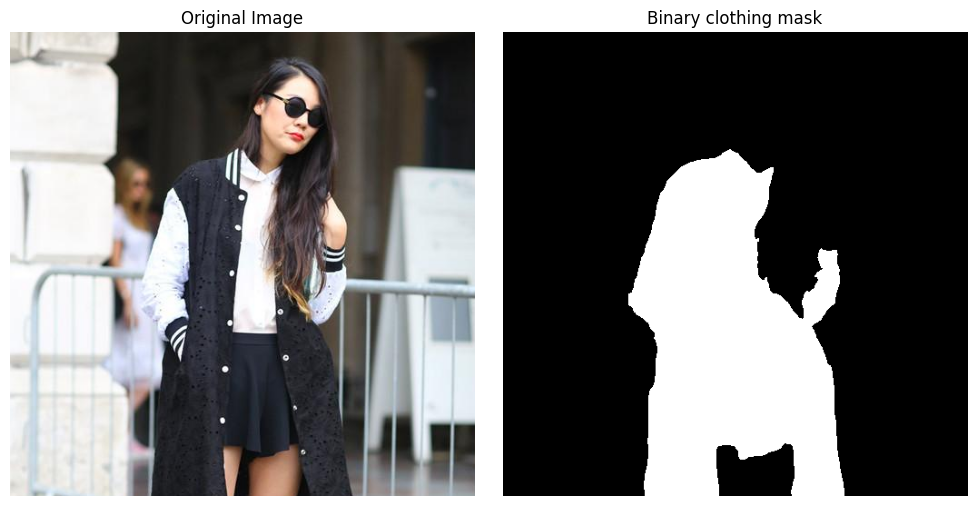

In [ ]:
# Disconsider skin and face from mask
clothing_classes = [
    4,  # Upper-clothes
    5,  # Skirt
    6,  # Pants
    7,  # Dress
    8,  # Belt
    9,  # Left-shoe
    10, # Right-shoe
    17  # Scarf
]

# Converts to mask
binary_mask_array = np.isin(pred_seg, clothing_classes).astype(np.uint8) * 255

mask_image = Image.fromarray(binary_mask_array, mode="L")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(image)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(mask_image, cmap="gray")
axes[1].set_title("Binary clothing mask")
axes[1].axis("off")

plt.tight_layout()
plt.show()

Creating new masks

In [ ]:
from tqdm.auto import tqdm
from pathlib import Path

In [ ]:
input_dir = Path("/content/drive/MyDrive/DiffVax_Data/train/images")
output_dir = Path("/content/drive/MyDrive/DiffVax_Data/train/masks_clothing")

In [ ]:
with torch.inference_mode():
    for img_path in tqdm(input_dir.iterdir(), desc="Processing Masks"):
        try:
            image = Image.open(img_path).convert("RGB")
            inputs = processor(images=image, return_tensors="pt").to(device)
            outputs = model(**inputs)
            logits = outputs.logits.cpu()

            # Upsampling
            upsampled_logits = nn.functional.interpolate(
                logits,
                size=image.size[::-1],
                mode="bilinear",
                align_corners=False,
            )

            pred_seg = upsampled_logits.argmax(dim=1)[0].numpy()
            binary_mask_array = np.isin(pred_seg, clothing_classes).astype(np.uint8) * 255

            mask_image = Image.fromarray(binary_mask_array, mode="L")
            output_filename = f"mask_clothing_{img_path.stem}.png"
            output_path = output_dir / output_filename

            mask_image.save(output_path)

        except Exception as e:
            print(f"Error while processing {img_path.name}: {e}")

print("Finish")

Processing Masks: 0it [00:00, ?it/s]

/tmp/ipykernel_1484/150464469.py:20: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask_image = Image.fromarray(binary_mask_array, mode="L")


Error while processing mask_image_0.png: [Errno 2] No such file or directory: '/content/drive/MyDrive/DiffVax_Data/train/images/mask_image_0.png'
Error while processing mask_image_2.png: [Errno 2] No such file or directory: '/content/drive/MyDrive/DiffVax_Data/train/images/mask_image_2.png'
Error while processing mask_image_4.png: [Errno 2] No such file or directory: '/content/drive/MyDrive/DiffVax_Data/train/images/mask_image_4.png'
Finish
